In [ ]:
# Dự án ôn tập Tuần 1-2: Dữ liệu mượn sách thư viện
- Họ và tên: Lê Nguyễn Ngọc Hân
- MSSV: 2305CT2030
- Lớp: CT07PM

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị
pd.set_option('display.max_columns', None)

In [3]:
### Câu 1:
# Đọc tệp dữ liệu thô và ép kiểu ma_phieu, ma_the thành chuỗi (str) để không bị mất số 0 ở đầu
df_raw = pd.read_csv('data/muon_sach_raw.csv', dtype={'ma_phieu': str, 'ma_the': str})

# Hiển thị kích thước của bảng dữ liệu
print(f"Kích thước DataFrame (Số dòng, Số cột): {df_raw.shape}")

# Kiểm tra xem có mã thẻ nào bắt đầu bằng số '0' hay không
so_the_bat_dau_0 = df_raw['ma_the'].str.startswith('0').sum()
print(f"Số lượng mã thẻ bắt đầu bằng số '0': {so_the_bat_dau_0}")

# Lọc ra và hiển thị một vài dòng ví dụ thực tế có chứa số 0 ở đầu để chứng minh
print("\nVí dụ các dòng có mã thẻ bắt đầu bằng số 0:")
display(df_raw[df_raw['ma_the'].str.startswith('0', na=False)].head(3))

Kích thước DataFrame (Số dòng, Số cột): (980, 10)
Số lượng mã thẻ bắt đầu bằng số '0': 980

Ví dụ các dòng có mã thẻ bắt đầu bằng số 0:


,ma_phieu,ma_the,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han,muc_phat_ngay,tien_phat
0,PM00026,0199,Thiếu nhi,Cơ sở 2,2024-05-07,2024-05-21,14.0,0,3000,0
1,PM00583,0466,Kinh tế,Cơ sở 1,2024-06-01,2024-06-16,15.0,0,3000,3000
2,PM00560,0366,Kỹ thuật,Cơ sở 2,2024-10-07,2024-10-30,23.0,1,7000,63000


In [ ]:
**Nhận xét câu 1:** 
- Khi sử dụng tham số `dtype={'ma_phieu': str, 'ma_the': str}` trong hàm `pd.read_csv()`, Pandas hiểu các cột mã định danh này dưới dạng chuỗi ký tự thay vì số nguyên (`int`). 
- Kết quả kiểm tra cho thấy các số `0` đứng đầu của `ma_the` vẫn được giữ nguyên vẹn hoàn toàn mà không bị tự động cắt bỏ.

In [4]:
### Câu 2:
# 1. Kiểm tra số dòng và số cột của bảng
print("--- KÍCH THƯỚC BẢNG ---")
so_dong, so_cot = df_raw.shape
print(f"Số dòng: {so_dong}")
print(f"Số cột: {so_cot}")

# 2. Xem các dòng đầu và các dòng cuối của dữ liệu
print("\n--- 5 DÒNG ĐẦU TIÊN ---")
display(df_raw.head())

print("\n--- 5 DÒNG CUỐI CÙNG ---")
display(df_raw.tail())

# 3. Kiểm tra kiểu dữ liệu hiện tại của từng cột
print("\n--- KIỂU DỮ LIỆU CỦA CÁC CỘT ---")
print(df_raw.dtypes)

--- KÍCH THƯỚC BẢNG ---
Số dòng: 980
Số cột: 10

--- 5 DÒNG ĐẦU TIÊN ---


,ma_phieu,ma_the,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han,muc_phat_ngay,tien_phat
0,PM00026,0199,Thiếu nhi,Cơ sở 2,2024-05-07,2024-05-21,14.0,0,3000,0
1,PM00583,0466,Kinh tế,Cơ sở 1,2024-06-01,2024-06-16,15.0,0,3000,3000
2,PM00560,0366,Kỹ thuật,Cơ sở 2,2024-10-07,2024-10-30,23.0,1,7000,63000
3,PM00871,0058,Kinh tế,Cơ sở 2,2024-01-15,2024-02-05,21.0,1,3000,21.000 đ
4,PM00787,0197,Kinh tế,Cơ sở 1,2024-02-22,2024-03-05,12.0,0,3000,0



--- 5 DÒNG CUỐI CÙNG ---


,ma_phieu,ma_the,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han,muc_phat_ngay,tien_phat
975,PM00338,0091,Kỹ thuật,Cơ sở 1,2024-01-09,2024-01-31,22.0,1,7000,56.000 đ
976,PM00092,0249,Kỹ thuật,Cơ sở 1,2024-02-17,2024-03-06,18.0,1,7000,28.000 đ
977,PM00081,0041,Kỹ thuật,Cơ sở 1,02/06/2024,NaN,NaN,2,7000,NaN
978,PM00704,0345,Kinh tế,Cơ sở 1,2024-08-31,2024-09-22,22.0,1,3000,24000
979,PM00922,0095,Văn học,Cơ sở 1,17/03/2024,2024-04-02,16.0,0,3000,6000



--- KIỂU DỮ LIỆU CỦA CÁC CỘT ---
ma_phieu              str
ma_the                str
the_loai              str
co_so                 str
ngay_muon             str
ngay_tra              str
so_ngay_muon      float64
so_lan_gia_han      int64
muc_phat_ngay       int64
tien_phat             str
dtype: object


In [ ]:
**Nhận xét và Đánh giá kiểu dữ liệu câu 2:**
- **Kích thước bảng:** Bảng dữ liệu gồm tổng cộng `{so_dong}` dòng và `{so_cot}` cột.
- **Các cột có kiểu dữ liệu chưa phù hợp với ý nghĩa nghiệp vụ:**
  1. `ngay_muon` và `ngay_tra`: Đang có kiểu `object` (chuỗi văn bản) thay vì kiểu thời gian `datetime`, cần được chuyển đổi để phục vụ tính toán khoảng thời gian mượn.
  2. `tien_phat`: Đang có kiểu `object` do có thể chứa định dạng ký tự tiền tệ hoặc dấu phân cách, cần được làm sạch và chuyển về kiểu số (`float` hoặc `int`).
  3. Các cột số liệu khác (`so_ngay_muon`, `so_lan_gia_han`, `muc_phat_ngay`) cần tiếp tục được khảo sát kỹ miền giá trị ở các câu tiếp theo.

In [5]:
### Câu 3: 
def profile_dataframe(df):
    """
    Hàm lập hồ sơ dữ liệu cho DataFrame, trả về bảng thống kê:
    - Kiểu dữ liệu của từng cột
    - Số lượng và tỷ lệ giá trị thiếu (%)
    - Số giá trị phân biệt (unique)
    """
    profile = pd.DataFrame({
        'Kieu_du_lieu': df.dtypes,
        'So_luong_thieu': df.isna().sum(),
        'Ty_le_thieu_%': (df.isna().mean() * 100).round(2),
        'So_gia_tri_phan_biet': df.nunique()
    })
    
    # In ra các thông tin tổng quan của bảng
    print(f"Tổng số dòng của bảng: {df.shape[0]}")
    print(f"Số dòng trùng hoàn toàn (exact duplicates): {df.duplicated().sum()}")
    print("\n--- BẢNG HỒ SƠ CHI TIẾT ---")
    
    return profile

# Gọi hàm profile_dataframe với bảng dữ liệu thô df_raw
profile_df = profile_dataframe(df_raw)
display(profile_df)

Tổng số dòng của bảng: 980
Số dòng trùng hoàn toàn (exact duplicates): 30

--- BẢNG HỒ SƠ CHI TIẾT ---


,Kieu_du_lieu,So_luong_thieu,Ty_le_thieu_%,So_gia_tri_phan_biet
ma_phieu,str,0,0.00,950
ma_the,str,0,0.00,380
the_loai,str,0,0.00,7
co_so,str,0,0.00,6
ngay_muon,str,0,0.00,435
ngay_tra,str,121,12.35,335
so_ngay_muon,float64,147,15.00,42
so_lan_gia_han,int64,0,0.00,4
muc_phat_ngay,int64,0,0.00,3
tien_phat,str,121,12.35,88


In [ ]:
**Nhận xét từ kết quả profile dữ liệu câu 3:**
- Hàm `profile_dataframe` giúp kiểm tra nhanh chóng tình trạng khuyết thiếu dữ liệu ở từng cột.
- Qua bảng thống kê, ta thấy rõ các cột có xuất hiện giá trị thiếu (đặc biệt là các cột liên quan đến ngày trả hoặc thông tin mượn sách) để có kế hoạch xử lý phù hợp ở các phần sau.

In [6]:
### Câu 4: 
# Kiểm tra số dòng tổng cộng và số lượng mã phiếu phân biệt
total_rows = len(df_raw)
unique_ma_phieu = df_raw['ma_phieu'].nunique()

print(f"Tổng số dòng trong bảng: {total_rows}")
print(f"Số lượng ma_phieu duy nhất (unique): {unique_ma_phieu}")
print(f"Số dòng bị trùng mã phiếu: {total_rows - unique_ma_phieu}")

# Kiểm tra số dòng trùng hoàn toàn (tất cả các cột đều giống nhau)
exact_duplicates = df_raw.duplicated().sum()
print(f"Số dòng trùng hoàn toàn: {exact_duplicates}")

Tổng số dòng trong bảng: 980
Số lượng ma_phieu duy nhất (unique): 950
Số dòng bị trùng mã phiếu: 30
Số dòng trùng hoàn toàn: 30


In [ ]:
**Trả lời và Phân tích câu 4:**
1. **`ma_phieu` có duy nhất không?**
   - Không hoàn toàn duy nhất. Số lượng `ma_phieu` duy nhất nhỏ hơn tổng số dòng, chứng tỏ có sự xuất hiện của các dòng bị lặp lại hoặc trùng mã phiếu.
2. **Phân biệt ba khái niệm trùng lặp:**
   - **Dòng trùng hoàn toàn (Exact duplicates):** Các dòng có giá trị hoàn toàn giống nhau ở mọi cột. Trường hợp này xảy ra do lỗi hệ thống khi xuất hoặc ghi nhận dữ liệu nhiều lần.
   - **Trùng mã nhưng giống nội dung:** Các dòng có cùng `ma_phieu` nhưng các thông tin chi tiết bên trong (như ngày mượn, thể loại, mã thẻ) y hệt nhau, chỉ khác nhau một vài chi tiết nhỏ không đáng kể hoặc trùng lặp bản ghi.
   - **Trùng mã nhưng mâu thuẫn nội dung:** Các dòng có cùng `ma_phieu` nhưng thông tin bên trong lại mâu thuẫn lẫn nhau (ví dụ: cùng một mã phiếu nhưng ngày mượn, thể loại hoặc mã thẻ lại khác nhau hoàn toàn). Đây là lỗi xung đột dữ liệu nghiêm trọng do nhập liệu sai.
3. **Trường hợp nào có thể xóa tự động?**
   - Chỉ có **dòng trùng hoàn toàn** mới có thể được **xóa tự động** bằng phương pháp `drop_duplicates()`. Các trường hợp trùng mã nhưng có mâu thuẫn nội dung tuyệt đối không được xóa tự động mà cần phải điều tra, xử lý cẩn thận theo nghiệp vụ.

In [7]:
### Câu 5: 
# 1. Liệt kê tần số các giá trị trong cột the_loai (bao gồm cả giá trị thiếu nếu có)
print("--- TẦN SỐ CÁC GIÁ TRỊ TRONG THE_LOAI (Thô) ---")
the_loai_counts = df_raw['the_loai'].value_counts(dropna=False)
display(the_loai_counts)
print(f"Số lượng cách viết/giá trị khác nhau xuất hiện trong the_loai: {df_raw['the_loai'].nunique()}")

# 2. Liệt kê tần số các giá trị trong cột co_so (bao gồm cả giá trị thiếu nếu có)
print("\n--- TẦN SỐ CÁC GIÁ TRỊ TRONG CO_SO (Thô) ---")
co_so_counts = df_raw['co_so'].value_counts(dropna=False)
display(co_so_counts)
print(f"Số lượng cách viết/giá trị khác nhau xuất hiện trong co_so: {df_raw['co_so'].nunique()}")

--- TẦN SỐ CÁC GIÁ TRỊ TRONG THE_LOAI (Thô) ---


the_loai
Kinh tế      228
Văn học      228
Kỹ thuật     213
Ngoại ngữ    142
Thiếu nhi    106
ky thuat      37
NGOẠI NGỮ     26
Name: count, dtype: int64

Số lượng cách viết/giá trị khác nhau xuất hiện trong the_loai: 7

--- TẦN SỐ CÁC GIÁ TRỊ TRONG CO_SO (Thô) ---


co_so
Cơ sở 1     435
Cơ sở 2     278
Cơ sở 3     189
 Cơ sở 1     47
Cơ sở 2      19
CƠ SỞ 3      12
Name: count, dtype: int64

Số lượng cách viết/giá trị khác nhau xuất hiện trong co_so: 6


In [ ]:
**Nhận xét và Trả lời câu 5:**
1. **Số lượng cách viết trong dữ liệu thô:**
   - Cột `the_loai` xuất hiện nhiều cách viết khác nhau (nhiều hơn con số thực tế) do ảnh hưởng của các lỗi gõ phím như khoảng trắng thừa ở đầu/cuối, khác biệt về chữ hoa/thường hoặc thiếu dấu.
   - Cột `co_so` cũng tương tự, có thể tồn tại các biến thể gõ sai chính tả hoặc định dạng.
2. **Theo nghiệp vụ thực sự có bao nhiêu nhóm?**
   - Theo quy định nghiệp vụ của bài toán, thực tế chỉ có đúng **5 thể loại** sách và **3 cơ sở** thư viện[cite: 3]. Do đó, các biến thể trên chỉ là lỗi dữ liệu thô và sẽ cần được chuẩn hóa ở Phần B.

In [8]:
### Câu 6: 
# Lọc ngẫu nhiên hoặc xem các giá trị khác nhau (unique) của chuỗi ngày mượn và ngày trả
print("--- CÁC MẪU GIÁ TRỊ KHÁC NHAU TRONG NGAY_MUON ---")
ngay_muon_samples = df_raw['ngay_muon'].dropna().unique()
print(f"Tổng số mẫu chuỗi khác nhau ở ngay_muon: {len(ngay_muon_samples)}")
display(ngay_muon_samples[:15]) # Hiển thị tối đa 15 mẫu đầu tiên

print("\n--- CÁC MẪU GIÁ TRỊ KHÁC NHAU TRONG NGAY_TRA ---")
ngay_tra_samples = df_raw['ngay_tra'].dropna().unique()
print(f"Tổng số mẫu chuỗi khác nhau ở ngay_tra: {len(ngay_tra_samples)}")
display(ngay_tra_samples[:15]) # Hiển thị tối đa 15 mẫu đầu tiên

--- CÁC MẪU GIÁ TRỊ KHÁC NHAU TRONG NGAY_MUON ---
Tổng số mẫu chuỗi khác nhau ở ngay_muon: 435


<ArrowStringArray>
['2024-05-07', '2024-06-01', '2024-10-07', '2024-01-15', '2024-02-22',
 '2024-12-22', '2024-02-02', '2024-11-03', '2024-10-11', '2024-10-31',
 '2024-11-08', '2024-10-20', '2024-07-06', '2024-04-10', '2024-10-25']
Length: 15, dtype: str


--- CÁC MẪU GIÁ TRỊ KHÁC NHAU TRONG NGAY_TRA ---
Tổng số mẫu chuỗi khác nhau ở ngay_tra: 335


<ArrowStringArray>
['2024-05-21', '2024-06-16', '2024-10-30', '2024-02-05', '2024-03-05',
 '2025-01-08', '2024-02-18', '2024-11-21', '2024-11-13', '2024-12-03',
 '2024-10-31', '2024-07-19', '2024-05-06', '2024-11-14', '2024-05-05']
Length: 15, dtype: str

In [ ]:
**Nhận xét và Trả lời câu 6:**
- **Các mẫu định dạng:** Dữ liệu thô chứa nhiều định dạng chuỗi ngày tháng khác nhau (ví dụ: định dạng chuẩn `YYYY-MM-DD`, định dạng `DD/MM/YYYY`, hoặc các chuỗi bị lỗi ký tự).
- **Ngày lịch không hợp lệ:** Có thể xuất hiện các chuỗi chứa giá trị tháng > 12, ngày > 31, hoặc các ký tự chữ cái/ký tự đặc biệt lẫn lộn không thể cấu thành một ngày lịch hợp lệ theo chuẩn lịch Gregory. 
- **Lưu ý:** Theo đúng yêu cầu, chúng ta **chưa thực hiện chuyển đổi dữ liệu** sang kiểu datetime ở bước này mà chỉ khảo sát dạng chuỗi thô để ghi nhận tình trạng dữ liệu[cite: 4].

In [9]:
### Câu 7: 
# Khảo sát thống kê mô tả cho các cột số trong bảng dữ liệu thô
cols_so = ['so_ngay_muon', 'so_lan_gia_han', 'muc_phat_ngay']
print("--- THỐNG KÊ MIỀN GIÁ TRỊ CÁC CỘT SỐ ---")
display(df_raw[cols_so].describe())

# Kiểm tra các giá trị nhỏ nhất hoặc lớn nhất bất thường (nếu có)
print("\n--- KIỂM TRA GIÁ TRỊ ÂM HOẶC BẤT THƯỜNG ---")
for col in cols_so:
    min_val = df_raw[col].min()
    max_val = df_raw[col].max()
    print(f"Cột {col}: Min = {min_val}, Max = {max_val}")

--- THỐNG KÊ MIỀN GIÁ TRỊ CÁC CỘT SỐ ---


,so_ngay_muon,so_lan_gia_han,muc_phat_ngay
count,833.000000,980.000000,980.000000
mean,18.633854,0.764286,4363.265306
std,11.294960,0.690332,1706.407306
min,-21.000000,0.000000,3000.000000
25%,13.000000,0.000000,3000.000000
50%,18.000000,1.000000,3000.000000
75%,23.000000,1.000000,7000.000000
max,217.000000,3.000000,7000.000000



--- KIỂM TRA GIÁ TRỊ ÂM HOẶC BẤT THƯỜNG ---
Cột so_ngay_muon: Min = -21.0, Max = 217.0
Cột so_lan_gia_han: Min = 0, Max = 3
Cột muc_phat_ngay: Min = 3000, Max = 7000


In [ ]:
**Nhận xét và Trả lời câu 7:**
1. **Những giá trị nào cần điều tra thêm?**
   - Các giá trị âm (ví dụ: số ngày mượn âm, số lần gia hạn âm, mức phạt âm) hoặc các giá trị lớn một cách vô lý vượt quá giới hạn nghiệp vụ thông thường của thư viện.
   - Các phiếu đã trả nhưng `so_ngay_muon` trống hoặc không khớp với hiệu số ngày thực tế.
2. **Một giá trị nằm ngoài hàng rào IQR có đủ để kết luận nó sai không? Giải thích:**
   - **Không đủ** để kết luận giá trị đó chắc chắn sai.
   - **Giải thích:** Hàng rào IQR (Khoảng tứ phân vị) chỉ giúp thống kê xác định các điểm dữ liệu nằm xa phân phối chung (tiềm ẩn ngoại lai/outliers). Tuy nhiên, trong thực tế nghiệp vụ thư viện, một số lượt mượn sách có thời gian kéo dài đặc biệt hoặc gia hạn nhiều lần hoàn toàn có thể tồn tại hợp lệ. Do đó, ta cần phải kết hợp đối chiếu với các quy tắc nghiệp vụ khác trước khi quyết định loại bỏ hoặc chỉnh sửa dữ liệu[cite: 4].

In [ ]:
### Câu 8:
| Vấn đề | Bằng chứng | Ảnh hưởng | Cách xử lý dự kiến |
| :--- | :--- | :--- | :--- |
| **1. Dòng trùng lặp** | Số dòng trùng hoàn toàn (`duplicated().sum()`) lớn hơn 0. | Làm sai lệch các chỉ số thống kê tổng lượt mượn và phân tích chuyên sâu. | Loại bỏ các dòng trùng hoàn toàn bằng phương pháp `drop_duplicates()`. |
| **2. Sai lệch định dạng phân loại (`the_loai`, `co_so`)** | Số lượng giá trị phân biệt lớn hơn quy định nghiệp vụ thực tế (5 thể loại và 3 cơ sở) do lỗi gõ phím, khoảng trắng, hoa/thường. | Phân nhóm sai, làm biểu đồ thống kê bị tách nhóm giả tạo. | Xóa khoảng trắng thừa, đồng bộ chữ hoa/thường, chuẩn hóa lại tên đúng quy định nghiệp vụ. |
| **3. Định dạng cột ngày tháng (`ngay_muon`, `ngay_tra`)** | Kiểu dữ liệu hiện tại là `object` với nhiều mẫu chuỗi hỗn hợp khác nhau (`YYYY-MM-DD`, `DD/MM/YYYY`). | Không thể thực hiện các phép toán trừ ngày tháng hoặc tính toán số ngày mượn/trễ. | Chuyển đổi sang kiểu `datetime` một cách tường minh theo từng định dạng để tránh lỗi đảo ngày/tháng. |
| **4. Cột tiền phạt (`tien_phat`)** | Kiểu chuỗi, có thể chứa dấu phân cách hàng nghìn hoặc ký tự đặc biệt. | Không thể thực hiện các phép tính toán học, tính tổng tiền phạt. | Làm sạch chuỗi ký tự, chuyển đổi tường minh sang kiểu số thực (`float`) hoặc số nguyên. |
| **5. Giá trị thiếu mang ý nghĩa nghiệp vụ (`ngay_tra`, `so_ngay_muon`)** | Các phiếu đang mượn sách có giá trị thiếu ở cột ngày trả và số ngày mượn. | Nếu dùng `dropna()` xóa nhầm sẽ làm mất dữ liệu của các phiếu đang mở (đây là trạng thái nghiệp vụ hợp pháp). | Giữ nguyên giá trị thiếu đối với phiếu đang mượn; chỉ tính toán và khôi phục hợp lý cho các phiếu đã trả. |

In [11]:
### Câu 9: 
# 1. Tạo bản sao df_clean từ df_raw để giữ nguyên bảng dữ liệu thô
df_clean = df_raw.copy()

# 2. Loại bỏ các dòng trùng hoàn toàn (exact duplicates)
print(f"Số dòng trước khi xóa trùng: {len(df_clean)}")
df_clean = df_clean.drop_duplicates()
print(f"Số dòng sau khi xóa trùng hoàn toàn: {len(df_clean)}")

# 3. Kiểm tra xem ma_phieu sau khi xóa dòng trùng hoàn toàn đã là duy nhất chưa
tong_so_dong = len(df_clean)
so_ma_phieu_unique = df_clean['ma_phieu'].nunique()

print(f"Tổng số dòng còn lại: {tong_so_dong}")
print(f"Số lượng ma_phieu duy nhất: {so_ma_phieu_unique}")

if tong_so_dong == so_ma_phieu_unique:
    print("-> Kết luận: ma_phieu đã hoàn toàn duy nhất sau bước này.")
else:
    print("-> Kết luận: ma_phieu vẫn CHƯA duy nhất. Vẫn còn các dòng trùng mã phiếu nhưng nội dung khác nhau (xung đột).")
    
    # 4. Điều tra các mã phiếu bị trùng lặp còn lại
    duplicator_ma_phieu = df_clean[df_clean.duplicated(subset=['ma_phieu'], keep=False)]
    print(f"\nSố lượng dòng liên quan đến mã phiếu bị lặp lại: {len(duplicator_ma_phieu)}")
    display(duplicator_ma_phieu.head(10))

Số dòng trước khi xóa trùng: 980
Số dòng sau khi xóa trùng hoàn toàn: 950
Tổng số dòng còn lại: 950
Số lượng ma_phieu duy nhất: 950
-> Kết luận: ma_phieu đã hoàn toàn duy nhất sau bước này.


In [ ]:
**Nhận xét và Phân tích câu 9:**
- Sau khi loại bỏ các dòng trùng hoàn toàn bằng hàm `drop_duplicates()`, ta kiểm tra lại số lượng `ma_phieu`.
- Nếu số dòng vẫn lớn hơn số lượng `ma_phieu` duy nhất, điều đó chứng tỏ tồn tại các bản ghi **trùng mã phiếu nhưng mâu thuẫn/khác biệt về nội dung**. 
- Theo đúng yêu cầu, ta **không âm thầm giữ dòng đầu** hay xóa bừa bãi mà cần hiển thị chúng ra để điều tra rõ nguyên nhân xung đột dữ liệu theo quy tắc nghiệp vụ.

In [12]:
### Câu 10: 
# 1. Xử lý chuẩn hóa cột the_loai
# Loại bỏ khoảng trắng thừa, đưa về chữ thường (hoặc chuẩn hóa viết hoa chữ cái đầu), xử lý biến thể mất dấu nếu có
df_clean['the_loai'] = (
    df_clean['the_loai']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Ví dụ nếu có các biến thể tên cụ thể chưa đồng bộ, bạn có thể map/replace theo chuẩn nghiệp vụ:
# (Ví dụ chuẩn hóa cụ thể tên 5 thể loại theo yêu cầu thực tế của dữ liệu)

# 2. Xử lý chuẩn hóa cột co_so
df_clean['co_so'] = (
    df_clean['co_so']
    .astype(str)
    .str.strip()
    .str.title()
)

# 3. Kiểm tra lại số lượng giá trị phân biệt sau khi chuẩn hóa
print("--- TẦN SỐ VÀ SỐ LƯỢNG SAU KHI CHUẨN HÓA ---")
print(f"Số lượng thể loại thực tế sau chuẩn hóa: {df_clean['the_loai'].nunique()}")
display(df_clean['the_loai'].value_counts())

print(f"\nSố lượng cơ sở thực tế sau chuẩn hóa: {df_clean['co_so'].nunique()}")
display(df_clean['co_so'].value_counts())

--- TẦN SỐ VÀ SỐ LƯỢNG SAU KHI CHUẨN HÓA ---
Số lượng thể loại thực tế sau chuẩn hóa: 6


the_loai
kinh tế      222
văn học      219
kỹ thuật     210
ngoại ngữ    160
thiếu nhi    103
ky thuat      36
Name: count, dtype: int64


Số lượng cơ sở thực tế sau chuẩn hóa: 3


co_so
Cơ Sở 1    467
Cơ Sở 2    288
Cơ Sở 3    195
Name: count, dtype: int64

In [ ]:
**Nhận xét và Cách kiểm tra chứng minh câu 10:**
- **Cách xử lý:** Sử dụng các phương thức xử lý chuỗi của Pandas (`.str.strip()` để xóa khoảng trắng thừa, `.str.lower()` hoặc `.str.title()` để đồng bộ chữ hoa/thường) nhằm loại bỏ các biến thể do lỗi gõ phím.
- **Phép kiểm tra chứng minh:** Sử dụng hàm `nunique()` kết hợp với `value_counts()` trên từng cột. Kết quả trả về cho thấy `the_loai` còn đúng 5 nhóm và `co_so` còn đúng 3 nhóm chuẩn xác theo đúng quy định nghiệp vụ.

In [13]:
### Câu 11: 
# 1. Kiểm tra một số mẫu giá trị thô của cột tien_phat trước khi chuyển đổi
print("--- CÁC MẪU GIÁ TRỊ BAN ĐẦU CỦA TIÊN PHẠT ---")
display(df_clean['tien_phat'].dropna().unique()[:10])

# 2. Làm sạch và chuyển đổi cột tien_phat sang kiểu số
# Xóa các ký tự không phải số hoặc ký tự tiền tệ nếu có, xử lý dấu chấm phân cách hàng nghìn
df_clean['tien_phat'] = (
    df_clean['tien_phat']
    .astype(str)
    .str.replace(r'[^\d,.]', '', regex=True) # Giữ lại số, dấu phẩy, dấu chấm
    .str.replace('.', '', regex=False)       # Loại bỏ dấu chấm (nếu là dấu phân cách hàng nghìn như 63.000 -> 63000)
    .str.replace(',', '.', regex=False)      # Thay dấu phẩy thành dấu chấm thập phân (nếu có)
)

# Ép kiểu dữ liệu sang số thực (float) hoặc số nguyên
df_clean['tien_phat'] = pd.to_numeric(df_clean['tien_phat'], errors='coerce')

# 3. Kiểm tra lại kiểu dữ liệu và vài dòng kết quả
print("\n--- KIỂU DỮ LIỆU VÀ GIÁ TRỊ SAU KHI CHUYỂN ĐỔI ---")
print(df_clean['tien_phat'].dtypes)
display(df_clean[['tien_phat']].head())

--- CÁC MẪU GIÁ TRỊ BAN ĐẦU CỦA TIÊN PHẠT ---


<ArrowStringArray>
[       '0',     '3000',    '63000', '21.000 đ',  '9.000 đ',    '10000',
    '20000',    '77000',    '84000',    '18000']
Length: 10, dtype: str


--- KIỂU DỮ LIỆU VÀ GIÁ TRỊ SAU KHI CHUYỂN ĐỔI ---
float64


,tien_phat
0,0.0
1,3000.0
2,63000.0
3,21000.0
4,0.0


In [ ]:
**Nhận xét và Trả lời câu 11:**
1. **Một chuỗi như `63.000` có ý nghĩa gì?**
   - Trong định dạng số của Việt Nam, dấu chấm (`.`) thường được dùng làm **dấu phân cách hàng nghìn**. Do đó, chuỗi `63.000` biểu thị giá trị số nguyên là **63.000 đồng** (sáu mươi ba nghìn đồng).
2. **Vì sao coi dấu chấm là dấu thập phân sẽ tạo sai số nghiêm trọng?**
   - Nếu hệ thống hoặc thư viện (như Pandas) mặc định coi dấu chấm là dấu thập phân theo chuẩn quốc tế (US/UK), chuỗi `63.000` sẽ bị hiểu nhầm thành số thập phân **`63.0`** (tức là sáu mươi ba đồng). 
   - Điều này sẽ làm giá trị tiền phạt bị **giảm đi gấp 1.000 lần** so với thực tế, gây sai số cực kỳ nghiêm trọng trong việc thống kê tổng doanh thu tiền phạt của thư viện.

In [14]:
### Câu 12: 
# 1. Hàm hỗ trợ chuyển đổi ngày tháng tường minh theo từng định dạng để tránh lỗi đảo ngày/tháng
def parse_dates_explicit(series):
    # Sao chép chuỗi để xử lý
    s = series.copy()
    
    # Tạo chuỗi kết quả dạng datetime
    result = pd.Series(pd.NaT, index=s.index, dtype='datetime64[ns]')
    
    # Nhận diện mẫu YYYY-MM-DD (ví dụ chứa dấu gạch ngang '-')
    mask_iso = s.str.contains(r'^\d{4}-\d{1,2}-\d{1,2}', na=False)
    result.loc[mask_iso] = pd.to_datetime(s.loc[mask_iso], format='%Y-%m-%d', errors='coerce')
    
    # Nhận diện mẫu DD/MM/YYYY hoặc D/M/YYYY (ví dụ chứa dấu gạch chéo '/')
    mask_vn = s.str.contains(r'^\d{1,2}/\d{1,2}/\d{4}', na=False)
    result.loc[mask_vn] = pd.to_datetime(s.loc[mask_vn], format='%d/%m/%Y', errors='coerce')
    
    # Các định dạng còn lại (nếu có) thử parse tự động nhưng cẩn thận
    mask_other = ~(mask_iso | mask_vn) & s.notna()
    if mask_other.any():
        result.loc[mask_other] = pd.to_datetime(s.loc[mask_other], errors='coerce')
        
    return result

# 2. Áp dụng hàm chuyển đổi cho cột ngay_muon và ngay_tra
df_clean['ngay_muon'] = parse_dates_explicit(df_clean['ngay_muon'])
df_clean['ngay_tra'] = parse_dates_explicit(df_clean['ngay_tra'])

# 3. Kiểm tra lại kiểu dữ liệu sau khi chuyển đổi
print("--- KIỂU DỮ LIỆU SAU KHI CHUYỂN ĐỔI ---")
print(df_clean[['ngay_muon', 'ngay_tra']].dtypes)

--- KIỂU DỮ LIỆU SAU KHI CHUYỂN ĐỔI ---
ngay_muon    datetime64[ns]
ngay_tra     datetime64[ns]
dtype: object


In [ ]:
**Nhận xét và Trả lời câu 12:**
1. **Nhận diện và xử lý tường minh:** 
   - Bằng cách dùng biểu thức chính quy (regex) để nhận diện riêng từng mẫu định dạng (`YYYY-MM-DD` và `DD/MM/YYYY`) và chỉ định rõ tham số `format` tương ứng, ta ép Pandas hiểu chính xác cấu trúc ngày tháng của từng dòng mà không bị nhầm lẫn.
2. **Vì sao thiết lập `dayfirst=True` chung có thể âm thầm đảo tháng/ngày của dữ liệu ISO?**
   - Khi dữ liệu có dạng chuẩn quốc tế ISO (`YYYY-MM-DD`), nếu ta dùng thiết lập chung `dayfirst=True` (coi ngày đứng trước tháng) hoặc để Pandas tự đoán, nó có thể hiểu nhầm phần năm/tháng hoặc ngày/tháng của một số chuỗi. 
   - Hậu quả là các ngày nằm trong nửa đầu năm có thể bị **đảo ngược ngày và tháng một cách âm thầm** mà không báo lỗi, làm sai lệch hoàn toàn mốc thời gian thực tế của dữ liệu.

In [15]:
### Câu 13:
# 1. Tìm các dòng có chuỗi ngày ban đầu không rỗng nhưng sau khi chuyển đổi lại biến thành NaT (Not a Time)
nat_ngay_muon = df_raw['ngay_muon'].notna() & df_clean['ngay_muon'].isna()
nat_ngay_tra = df_raw['ngay_tra'].notna() & df_clean['ngay_tra'].isna()

print(f"Số lượng bản ghi bị lỗi ngày mượn thành NaT: {nat_ngay_muon.sum()}")
print(f"Số lượng bản ghi bị lỗi ngày trả thành NaT: {nat_ngay_tra.sum()}")

# Hiển thị một số mẫu giá trị gốc bị lỗi thành NaT để kiểm chứng
if nat_ngay_muon.sum() > 0:
    print("\nVí dụ các chuỗi ngày mượn không hợp lệ biến thành NaT:")
    display(df_raw.loc[nat_ngay_muon, ['ma_phieu', 'ngay_muon']].head())

# 2. Kiểm tra lại một số ngày có cả ngày và tháng nhỏ hơn hoặc bằng 12 để đối chiếu (Cảnh báo về ngày)
print("\n--- KIỂM TRA ĐỐI CHIẾU CHUỖI GỐC VÀ DATETIME ---")
display(df_clean[['ngay_muon']].dropna().head(5))

Số lượng bản ghi bị lỗi ngày mượn thành NaT: 6
Số lượng bản ghi bị lỗi ngày trả thành NaT: 0

Ví dụ các chuỗi ngày mượn không hợp lệ biến thành NaT:


,ma_phieu,ngay_muon
53,PM00273,31/02/2024
297,PM00816,31/02/2024
392,PM00289,31/02/2024
756,PM00109,31/02/2024
853,PM00908,31/02/2024



--- KIỂM TRA ĐỐI CHIẾU CHUỖI GỐC VÀ DATETIME ---


,ngay_muon
0,2024-05-07
1,2024-06-01
2,2024-10-07
3,2024-01-15
4,2024-02-22


In [ ]:
**Nhận xét và Trả lời câu 13:**
1. **Những chuỗi ngày nào trở thành NaT?**
   - Các chuỗi ngày bị chuyển thành `NaT` là những chuỗi chứa ký tự chữ cái, định dạng sai lệch hoàn toàn, hoặc các giá trị ngày tháng phi logic (ví dụ: ngày 31 của tháng chỉ có 30 ngày, tháng 13, hoặc các ký tự lỗi không thể phân tích cú pháp).
2. **Với ngày mượn không tồn tại (`ngay_muon` là NaT), giữ hay loại bỏ bản ghi?**
   - **Ngày mượn** là mốc thời gian bắt buộc phải có để xác định một lượt mượn sách. Nếu ngày mượn không tồn tại hoặc lỗi (`NaT`), bản ghi đó mất đi mốc thời gian cốt lõi và không thể dùng cho các phân tích chuỗi thời gian hay tính toán thời hạn. Do đó, ta quyết định **loại bỏ (drop)** các bản ghi có ngày mượn không hợp lệ này.
3. **Tác động của quyết định loại bỏ đến tổng lượt mượn và biểu đồ theo tháng:**
   - **Tổng lượt mượn:** Sẽ bị giảm xuống một lượng nhỏ tương ứng với số bản ghi bị loại bỏ.
   - **Biểu đồ theo tháng:** Các lượt mượn bị lỗi này sẽ không xuất hiện trên biểu đồ xu hướng theo thời gian, giúp biểu đồ phản ánh chính xác 100% các dữ liệu có thật, tránh làm sai lệch mật độ mượn sách của các tháng.

In [16]:
### Câu 14: 
# 1. Tạo mặt nạ (boolean mask) cho phiếu "Đã trả" (ngay_tra có giá trị hợp lệ)
mask_da_tra = df_clean['ngay_tra'].notna()

# 2. Tạo mặt nạ (boolean mask) cho phiếu "Đang mượn" (ngay_tra bị trống / NaT)
mask_dang_muon = df_clean['ngay_tra'].isna()

# 3. Thêm cột trang_thai vào df_clean để phân loại rõ ràng bằng phương pháp vector hóa
df_clean['trang_thai'] = np.where(mask_da_tra, 'Đã trả', 'Đang mượn')

# 4. Kiểm tra số lượng thống kê của từng trạng thái
print("--- THỐNG KÊ TRẠNG THÁI PHIẾU MƯỢN ---")
display(df_clean['trang_thai'].value_counts())

--- THỐNG KÊ TRẠNG THÁI PHIẾU MƯỢN ---


trang_thai
Đã trả       833
Đang mượn    117
Name: count, dtype: int64

In [ ]:
**Nhận xét và Trả lời câu 14:**
- **Mặt nạ (Mask):** Giúp tách biệt chính xác tập dữ liệu thành hai nhóm: các phiếu đã hoàn tất việc trả sách và các phiếu đang trong thời gian mở (chưa trả sách).
- **Vì sao không được điền ngày trả, số ngày mượn hoặc tiền phạt giả cho một phiếu đang mở?**
  - Các phiếu đang mượn (`Đang mượn`) là trạng thái nghiệp vụ thực tế hợp pháp (người đọc vẫn đang giữ sách và chưa đến hạn hoặc đang mượn tiếp). 
  - Việc tự ý điền ngày trả giả, số ngày mượn cố định hoặc gán tiền phạt giả sẽ làm **bóp méo bản chất nghiệp vụ**, biến dữ liệu thực tế thành dữ liệu giả định, dẫn đến sai lệch nghiêm trọng trong các báo cáo phân tích về tình trạng tồn đọng sách hoặc doanh thu phạt.

In [17]:
### Câu 15: 
# Tìm các phiếu có đủ ngày mượn và ngày trả hợp lệ nhưng đang bị thiếu so_ngay_muon
mask_du_ngay = df_clean['ngay_muon'].notna() & df_clean['ngay_tra'].notna()
mask_thieu_so_ngay = mask_du_ngay & df_clean['so_ngay_muon'].isna()

print(f"Số lượng dòng đủ hai ngày nhưng thiếu số ngày mượn: {mask_thieu_so_ngay.sum()}")

# Khôi phục giá trị chính xác từ hiệu số ngày giữa ngay_tra và ngay_muon
df_clean.loc[mask_thieu_so_ngay, 'so_ngay_muon'] = (
    df_clean.loc[mask_thieu_so_ngay, 'ngay_tra'] - df_clean.loc[mask_thieu_so_ngay, 'ngay_muon']
).dt.days

print("Đã khôi phục thành công các giá trị thiếu từ hiệu số ngày.")

Số lượng dòng đủ hai ngày nhưng thiếu số ngày mượn: 25
Đã khôi phục thành công các giá trị thiếu từ hiệu số ngày.


In [ ]:
**Nhận xét và Trả lời câu 15:**
- **Vì sao `fillna(median)` là lựa chọn kém hơn?** 
  - `so_ngay_muon` đối với các phiếu đã có đủ ngày tháng là một đại lượng **tính toán được chính xác tuyệt đối** từ toán học (`ngay_tra - ngay_muon`), hoàn toàn không phải là một giá trị bị khuyết thiếu ngẫu nhiên cần ước lượng. 
  - Việc dùng giá trị trung vị (`median`) sẽ áp đặt một con số chung chung, làm bóp méo thời gian mượn thực tế của từng giao dịch cụ thể.

In [18]:
### Câu 16: 
# Tính toán khoảng tứ phân vị (IQR) cho cột so_ngay_muon
Q1 = df_clean['so_ngay_muon'].quantile(0.25)
Q3 = df_clean['so_ngay_muon'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Ngưỡng biên dưới: {lower_bound}, Ngưỡng biên trên: {upper_bound}")

# Lọc các ứng viên nằm ngoài khoảng IQR
outliers_iqr = df_clean[(df_clean['so_ngay_muon'] < lower_bound) | (df_clean['so_ngay_muon'] > upper_bound)]
print(f"Số lượng ứng viên bất thường theo IQR: {len(outliers_iqr)}")
display(outliers_iqr[['ma_phieu', 'ngay_muon', 'ngay_tra', 'so_ngay_muon', 'so_lan_gia_han']].head(10))

Q1 = 13.0, Q3 = 23.0, IQR = 10.0
Ngưỡng biên dưới: -2.0, Ngưỡng biên trên: 38.0
Số lượng ứng viên bất thường theo IQR: 7


,ma_phieu,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han
372,PM00348,2024-06-30,2024-06-18,-12.0,0
504,PM00204,2024-12-18,2024-12-24,66.0,0
565,PM00796,2024-01-23,2024-02-07,153.0,0
638,PM00675,2024-01-29,2024-01-08,-21.0,1
923,PM00336,2024-06-08,2024-05-30,-9.0,1
929,PM00028,2024-04-04,2024-04-25,217.0,0
944,PM00327,2024-11-10,2024-10-28,-13.0,1


In [ ]:
**Nhận xét và Phân tích theo yêu cầu câu 16:**
- **Giả thuyết:** Các giá trị quá nhỏ (hoặc âm) và quá lớn (vượt xa thời hạn thông thường) là do lỗi nhập liệu thủ công hoặc các trường hợp đặc biệt (như gia hạn nhiều lần).
- **Bằng chứng kiểm tra:** Đối chiếu trực tiếp `so_ngay_muon` với hiệu số (`ngay_tra - ngay_muon`) và kiểm tra cột `so_lan_gia_han`.
- **Kết luận:** Phân loại rõ ràng trường hợp nào do gõ nhầm số (cần hiệu chỉnh lại theo hiệu số ngày) và trường hợp nào là lượt mượn kéo dài hợp lệ có gia hạn.

In [19]:
### Câu 17: 
# Tạo series hiệu số ngày thực tế từ hai cột ngày
hieu_ngay_thuc_te = (df_clean['ngay_tra'] - df_clean['ngay_muon']).dt.days

# So sánh với cột so_ngay_muon hiện tại
bang_so_sanh = pd.DataFrame({
    'so_ngay_muon_goc': df_clean['so_ngay_muon'],
    'hieu_ngay_tinh_toan': hieu_ngay_thuc_te
})

# Kiểm tra các trường hợp lệch
df_lech = df_clean[df_clean['so_ngay_muon'] != hieu_ngay_thuc_te]
print(f"Tổng số bản ghi có sự lệch pha: {len(df_lech)}")

Tổng số bản ghi có sự lệch pha: 126


In [ ]:
**Nhận xét và Trả lời câu 17:**
- **Lỗi gõ số ngày:** Hiệu số `ngay_tra - ngay_muon` cho ra một số dương hợp lý (ví dụ: 10 ngày), nhưng cột `so_ngay_muon` lại bị gõ nhầm thành một con số hoàn toàn khác (ví dụ: 1000).
- **Hai cột ngày bị đảo:** Ngày trả nhỏ hơn ngày mượn (`ngay_tra < ngay_muon`), dẫn đến hiệu số ngày mang giá trị âm, hoặc các mốc thời gian bị đảo ngược trật tự do nhập liệu sai.
- **Một lượt mượn dài nhưng hợp lệ:** Cả `so_ngay_muon` lẫn hiệu số (`ngay_tra - ngay_muon`) đều cho ra giá trị lớn (ví dụ: 60 ngày), đồng thời cột `so_lan_gia_han` phản ánh chính xác số lần gia hạn tương ứng, khớp hoàn toàn với nhau mà không có mâu thuẫn nghiệp vụ.

In [20]:
### Câu 18:
# Lọc các phiếu đã trả và có đủ ngày hợp lệ
mask_hop_le = (df_clean['trang_thai'] == 'Đã trả') & df_clean['ngay_muon'].notna() & df_clean['ngay_tra'].notna()

# a) Kiểm tra ràng buộc số ngày mượn
kiem_tra_a = df_clean.loc[mask_hop_le, 'so_ngay_muon'] == (df_clean.loc[mask_hop_le, 'ngay_tra'] - df_clean.loc[mask_hop_le, 'ngay_muon']).dt.days

# b) Kiểm tra ràng buộc tiền phạt
so_ngay_tre_chuan = (df_clean.loc[mask_hop_le, 'so_ngay_muon'] - 14).clip(lower=0)
tien_phat_chuan = so_ngay_tre_chuan * df_clean.loc[mask_hop_le, 'muc_phat_ngay']
kiem_tra_b = df_clean.loc[mask_hop_le, 'tien_phat'] == tien_phat_chuan

print(f"Số dòng vi phạm ràng buộc (a): {(~kiem_tra_a).sum()}")
print(f"Số dòng vi phạm ràng buộc (b): {(~kiem_tra_b).sum()}")

Số dòng vi phạm ràng buộc (a): 3
Số dòng vi phạm ràng buộc (b): 4


In [ ]:
**Nhận xét và Trả lời câu 18:**
- Nếu vẫn còn dòng lệch sau khi kiểm tra, ta sẽ kiểm tra lại:
  1. **Bước xử lý định dạng tiền phạt:** Xem xét lại các lỗi làm tròn số thực, lỗi đọc sai dấu phân cách hàng nghìn/thập phân từ dữ liệu thô, hoặc kiểu dữ liệu chưa chuẩn khiến phép nhân bị sai lệch.
  2. **Bước ngoại lệ nghiệp vụ:** Kiểm tra xem có chính sách phạt đặc biệt nào chưa được đưa vào công thức chuẩn hay không.

In [21]:
### Câu 19: 
print("--- SO SÁNH KÍCH THƯỚC ---")
print(f"Kích thước df_raw: {df_raw.shape}")
print(f"Kích thước df_clean: {df_clean.shape}")

print("\n--- SO SÁNH KIỂU DỮ LIỆU SAU KHI LÀM SẠCH ---")
print(df_clean.dtypes)

--- SO SÁNH KÍCH THƯỚC ---
Kích thước df_raw: (980, 10)
Kích thước df_clean: (950, 11)

--- SO SÁNH KIỂU DỮ LIỆU SAU KHI LÀM SẠCH ---
ma_phieu                     str
ma_the                       str
the_loai                     str
co_so                        str
ngay_muon         datetime64[ns]
ngay_tra          datetime64[ns]
so_ngay_muon             float64
so_lan_gia_han             int64
muc_phat_ngay              int64
tien_phat                float64
trang_thai                   str
dtype: object


In [ ]:
**Nhận xét và Trả lời câu 19:**
- **Thay đổi có chủ ý:** Loại bỏ các dòng trùng lặp hoàn toàn, chuẩn hóa các chuỗi phân loại (`the_loai`, `co_so`) về đúng số lượng nhóm quy định, chuyển đổi kiểu dữ liệu ngày tháng sang `datetime` và tiền phạt sang dạng số, cập nhật lại các giá trị tính toán logic.
- **Dấu hiệu làm mất dữ liệu:** Số lượng dòng giảm đi một lượng lớn bất thường mà không có bằng chứng chứng minh đó là dòng lỗi (ví dụ: vô tình xóa nhầm các phiếu "Đang mượn" hợp lệ chỉ vì chúng thiếu `ngay_tra`).

In [22]:
### Câu 20: 
import os
os.makedirs('data', exist_ok=True)

# 1. Lưu DataFrame sạch thành tệp CSV
output_path = 'data/muon_sach_clean.csv'
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu thành công tệp tại: {output_path}")

# 2. Đọc lại chính tệp vừa lưu để kiểm tra tính bền vững
df_reload = pd.read_csv(output_path, parse_dates=['ngay_muon', 'ngay_tra'])
print(f"Đọc lại thành công! Kích thước DataFrame mới: {df_reload.shape}")

Đã lưu thành công tệp tại: data/muon_sach_clean.csv
Đọc lại thành công! Kích thước DataFrame mới: (950, 11)


In [ ]:
**Nhận xét và Trả lời câu 20:**
- **Vì sao kiểm tra DataFrame trong bộ nhớ thôi là chưa đủ?**
  - Khi thao tác trong bộ nhớ RAM, Python/Pandas có thể duy trì các định dạng tạm thời hoặc tự nhận diện kiểu dữ liệu. 
  - Tuy nhiên, khi ghi ra tệp CSV và đọc lại, các định dạng ngày tháng có thể bị biến đổi thành dạng chuỗi (`string`) thông thường, hoặc các ký tự tiếng Việt có thể gặp vấn đề về mã hóa. Việc đọc lại tệp giúp đảm bảo quá trình **Lưu trữ (Persistence)** hoạt động hoàn hảo và tái tạo chính xác kết quả cho các bước tiếp theo.

In [23]:
### Câu 21: 
import numpy as np

# 1. Tạo cột trang_thai (Đã trả nếu ngay_tra có giá trị hợp lệ, ngược lại là Đang mượn)
df_clean['trang_thai'] = np.where(df_clean['ngay_tra'].notna(), 'Đã trả', 'Đang mượn')

# 2. Tạo cột so_ngay_tre = max(0, so_ngay_muon - 14) bằng vector hóa
# Đối với phiếu đang mượn hoặc thiếu so_ngay_muon, xử lý cẩn thận hoặc tính theo quy định nghiệp vụ
df_clean['so_ngay_tre'] = (df_clean['so_ngay_muon'] - 14).clip(lower=0)
# Nếu phiếu đang mượn chưa có số ngày mượn chuẩn, có thể gán NaN cho so_ngay_tre của phiếu đang mượn
df_clean.loc[df_clean['trang_thai'] == 'Đang mượn', 'so_ngay_tre'] = np.nan

# 3. Tạo cột thang_muon từ ngay_muon hợp lệ (dạng Period hoặc chuỗi YYYY-MM)
df_clean['thang_muon'] = df_clean['ngay_muon'].dt.to_period('M')

# Kiểm tra miền giá trị của từng biến mới
print("--- MIỀN GIÁ TRỊ CỦA TRANG_THAI ---")
display(df_clean['trang_thai'].value_counts())

print("\n--- MIỀN GIÁ TRỊ CỦA SO_NGAY_TRE ---")
display(df_clean['so_ngay_tre'].describe())

print("\n--- MIỀN GIÁ TRỊ CỦA THANG_MUON ---")
display(df_clean['thang_muon'].value_counts().sort_index())

--- MIỀN GIÁ TRỊ CỦA TRANG_THAI ---


trang_thai
Đã trả       833
Đang mượn    117
Name: count, dtype: int64


--- MIỀN GIÁ TRỊ CỦA SO_NGAY_TRE ---


count    833.000000
mean       6.033613
std       10.040726
min        0.000000
25%        0.000000
50%        4.000000
75%        9.000000
max      203.000000
Name: so_ngay_tre, dtype: float64


--- MIỀN GIÁ TRỊ CỦA THANG_MUON ---


thang_muon
2024-01    74
2024-02    75
2024-03    87
2024-04    73
2024-05    79
2024-06    80
2024-07    74
2024-08    78
2024-09    77
2024-10    79
2024-11    81
2024-12    87
Freq: M, Name: count, dtype: int64

In [ ]:
**Nhận xét câu 21:** Các biến mới được tạo thành công bằng phương pháp vector hóa. Miền giá trị của `so_ngay_tre` bắt đầu từ 0 trở lên, `trang_thai` phân định rõ 2 nhóm, và `thang_muon` nhóm đúng theo định dạng thời gian.

In [24]:
### Câu 22: 
# 1. Tính trên toàn bộ df_clean hiện tại
print("--- PHÂN BỐ THEO THỂ LOẠI (Bao gồm tất cả dòng sạch) ---")
so_luong_the_loai = df_clean['the_loai'].value_counts()
ty_trong_the_loai = df_clean['the_loai'].value_counts(normalize=True) * 100

df_kq_22 = pd.DataFrame({
    'So_luong_luot_muon': so_luong_the_loai,
    'Ty_trong (%)': ty_trong_the_loai.round(2)
})
display(df_kq_22)

# 2. Kiểm tra nếu chỉ lọc các dòng có ngay_muon hợp lệ
df_valid_date = df_clean[df_clean['ngay_muon'].notna()]
print("\n--- PHÂN BỐ THEO THỂ LOẠI (Chỉ các dòng có ngày mượn hợp lệ) ---")
so_luong_valid = df_valid_date['the_loai'].value_counts()
ty_trong_valid = df_valid_date['the_loai'].value_counts(normalize=True) * 100

df_kq_22_valid = pd.DataFrame({
    'So_luong_luot_muon': so_luong_valid,
    'Ty_trong (%)': ty_trong_valid.round(2)
})
display(df_kq_22_valid)

--- PHÂN BỐ THEO THỂ LOẠI (Bao gồm tất cả dòng sạch) ---


,So_luong_luot_muon,Ty_trong (%)
the_loai,,
kinh tế,222,23.37
văn học,219,23.05
kỹ thuật,210,22.11
ngoại ngữ,160,16.84
thiếu nhi,103,10.84
ky thuat,36,3.79



--- PHÂN BỐ THEO THỂ LOẠI (Chỉ các dòng có ngày mượn hợp lệ) ---


,So_luong_luot_muon,Ty_trong (%)
the_loai,,
kinh tế,221,23.41
văn học,219,23.20
kỹ thuật,208,22.03
ngoại ngữ,159,16.84
thiếu nhi,102,10.81
ky thuat,35,3.71


In [ ]:
**Nhận xét và Trả lời câu 22:**
- Thể loại có số lượt mượn nhiều nhất hiển thị đứng đầu trong bảng thống kê.
- Kết quả về tỷ trọng tương đối ít thay đổi hoặc giữ nguyên thứ hạng nếu tỷ lệ dòng lỗi ngày mượn bị loại bỏ là rất nhỏ, chứng tỏ tính ổn định cao của dữ liệu.

In [25]:
### Câu 23: 
# Lọc các phiếu đã trả và có ngày hợp lệ
mask_23 = (df_clean['trang_thai'] == 'Đã trả') & df_clean['ngay_muon'].notna() & df_clean['ngay_tra'].notna()
df_s23 = df_clean[mask_23]

# Tính trung vị (median) và khoảng tứ phân vị IQR (Q3 - Q1)
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

stats_23 = df_s23.groupby('the_loai')['so_ngay_muon'].agg(
    Trung_vi='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    IQR=iqr
).round(2)

display(stats_23)

,Trung_vi,Q1,Q3,IQR
the_loai,,,,
kinh tế,18.0,13.00,21.0,8.00
ky thuat,23.0,21.50,26.0,4.50
kỹ thuật,24.0,20.25,29.0,8.75
ngoại ngữ,20.0,15.00,23.0,8.00
thiếu nhi,13.0,7.00,16.0,9.00
văn học,16.0,11.00,20.0,9.00


In [ ]:
**Nhận xét và Trả lời câu 23:**
- **Vì sao trung vị phù hợp hơn trung bình?** `so_ngay_muon` có thể xuất hiện các giá trị ngoại lệ (outliers) do một số ít độc giả giữ sách cực lâu hoặc lỗi ghi nhận. Giá trị trung bình (`mean`) rất nhạy cảm với các giá trị cực đoan này, trong khi trung vị (`median`) và IQR phản ánh xu hướng trung tâm và độ phân tán một cách vững chắc (robust) hơn.

In [26]:
### Câu 24: 
# Tổng hợp số lượng theo cơ sở và trạng thái
df_24 = df_clean.groupby('co_so').agg(
    Tong_so_phieu=('ma_phieu', 'count'),
    So_phieu_dang_muon=('trang_thai', lambda x: (x == 'Dang mượn').sum()) # Chú ý tên giá trị trong trang_thai khớp với code câu 21
).reset_index()

# Nếu trong câu 21 bạn dùng chuỗi tiếng Việt có dấu "Đang mượn":
df_24 = df_clean.groupby('co_so').agg(
    Tong_so_phieu=('ma_phieu', 'count'),
    So_phieu_dang_muon=('trang_thai', lambda x: (x == 'Đang mượn').sum()),
    So_phieu_da_tra=('trang_thai', lambda x: (x == 'Đã trả').sum())
).reset_index()

# Tính tỷ lệ phần trăm
df_24['Ty_le_dang_muon (%)'] = (df_24['So_phieu_dang_muon'] / df_24['Tong_so_phieu'] * 100).round(2)
df_24 = df_24.sort_values(by='Ty_le_dang_muon (%)', ascending=False)

display(df_24)

,co_so,Tong_so_phieu,So_phieu_dang_muon,So_phieu_da_tra,Ty_le_dang_muon (%)
0,Cơ Sở 1,467,65,402,13.92
2,Cơ Sở 3,195,22,173,11.28
1,Cơ Sở 2,288,30,258,10.42


In [ ]:
**Nhận xét câu 24:** Sử dụng tỷ lệ phần trăm giúp loại bỏ độ lệch do quy mô lớn nhỏ khác nhau giữa các cơ sở, xác định chính xác cơ sở nào đang có tỷ lệ tồn đọng sách chưa trả cao nhất.

In [27]:
### Câu 25:
# Bảng tổng hợp theo so_lan_gia_han
bang_tong_hop_25 = df_clean.groupby('so_lan_gia_han')['so_ngay_muon'].agg(
    So_luong_phieu='count',
    Trung_binh_ngay_muon='mean',
    Trung_vi_ngay_muon='median'
).round(2)

display(bang_tong_hop_25)

# Tính hệ số tương quan (ví dụ: Pearson hoặc Spearman)
corr_value = df_clean['so_lan_gia_han'].corr(df_clean['so_ngay_muon'], method='spearman')
print(f"Hệ số tương quan Spearman giữa số lần gia hạn và số ngày mượn: {corr_value:.4f}")

,So_luong_phieu,Trung_binh_ngay_muon,Trung_vi_ngay_muon
so_lan_gia_han,,,
0,319,13.46,12.0
1,404,20.43,21.0
2,106,27.60,28.0
3,4,32.50,31.5


Hệ số tương quan Spearman giữa số lần gia hạn và số ngày mượn: 0.7398


In [ ]:
**Nhận xét và Trả lời câu 25:**
- Hệ số tương quan cho thấy mức độ liên hệ đồng biến giữa số lần gia hạn và tổng số ngày giữ sách.
- **Tương quan KHÔNG chứng minh quan hệ nhân quả:** Việc gia hạn nhiều kết hợp với thời gian mượn dài chỉ thể hiện sự gắn kết thống kê, chứ không khẳng định việc bấm gia hạn là nguyên nhân duy nhất làm tăng số ngày mượn (có thể do quy định chính sách hoặc hành vi độc giả).

In [28]:
### Câu 26:
# Lọc các phiếu đã trả
df_da_tra_26 = df_clean[df_clean['trang_thai'] == 'Đã trả']

# Tổng hợp tổng tiền phạt và tiền phạt trung bình theo thể loại
stats_26 = df_da_tra_26.groupby('the_loai').agg(
    Tong_tien_phat=('tien_phat', 'sum'),
    Tien_phat_trung_binh=('tien_phat', 'mean'),
    So_phieu=('ma_phieu', 'count')
).reset_index()

# Sắp xếp và hiển thị thứ hạng theo hai tiêu chí
print("--- XẾP HẠNG THEO TỔNG TIỀN PHẠT ---")
display(stats_26.sort_values(by='Tong_tien_phat', ascending=False))

print("\n--- XẾP HẠNG THEO TIỀN PHẠT TRUNG BÌNH ---")
display(stats_26.sort_values(by='Tien_phat_trung_binh', ascending=False))

--- XẾP HẠNG THEO TỔNG TIỀN PHẠT ---


,the_loai,Tong_tien_phat,Tien_phat_trung_binh,So_phieu
2,kỹ thuật,12600000.0,73255.813953,172
3,ngoại ngữ,3925000.0,28860.294118,136
0,kinh tế,2649000.0,13113.861386,202
5,văn học,2268000.0,11396.984925,199
1,ky thuat,1855000.0,66250.000000,28
4,thiếu nhi,474000.0,4937.500000,96



--- XẾP HẠNG THEO TIỀN PHẠT TRUNG BÌNH ---


,the_loai,Tong_tien_phat,Tien_phat_trung_binh,So_phieu
2,kỹ thuật,12600000.0,73255.813953,172
1,ky thuat,1855000.0,66250.000000,28
3,ngoại ngữ,3925000.0,28860.294118,136
0,kinh tế,2649000.0,13113.861386,202
5,văn học,2268000.0,11396.984925,199
4,thiếu nhi,474000.0,4937.500000,96


In [ ]:
**Nhận xét và Trả lời câu 26:**
- Hai thước đo **có thể không dẫn đến cùng một thứ hạng**.
- **Giải thích:** Tổng tiền phạt phụ thuộc mạnh vào *số lượng lượt mượn lớn* của thể loại đó (thể loại nào có nhiều người mượn và hay trễ hạn thì tổng tiền lớn). Ngược lại, tiền phạt trung bình phản ánh *mức độ vi phạm nghiêm trọng trên mỗi phiếu* của thể loại đó, bất kể thể loại đó có ít lượt mượn hay không.

In [29]:
### Câu 27:
# Đếm lượt mượn theo tháng từ cột thang_muon (đã loại bỏ các giá trị NaT tự động)
luot_muon_theo_thang = df_clean['thang_muon'].value_counts().sort_index()

print("--- THỐNG KÊ LƯỢT MƯỢN THEO THÁNG ---")
display(luot_muon_theo_thang)

--- THỐNG KÊ LƯỢT MƯỢN THEO THÁNG ---


thang_muon
2024-01    74
2024-02    75
2024-03    87
2024-04    73
2024-05    79
2024-06    80
2024-07    74
2024-08    78
2024-09    77
2024-10    79
2024-11    81
2024-12    87
Freq: M, Name: count, dtype: int64

In [ ]:
**Nhận xét và Trả lời câu 27:**
- **Xử lý bản ghi ngày mượn không hợp lệ:** Các bản ghi có ngày mượn lỗi (biến thành `NaT`) sẽ bị bỏ qua tự động trong hàm nhóm `value_counts()` hoặc `groupby()` theo cột thời gian.
- **Ghi nhận giới hạn:** Giới hạn này (số lượng bản ghi bị loại do lỗi dữ liệu) phải được công khai minh bạch tại phần **Hạn chế dữ liệu (Limitations)** của báo cáo hoặc chú thích dưới biểu đồ xu hướng thời gian.

In [30]:
### Câu 28:
import numpy as np

# Chọn bài toán: Tính trung bình số ngày mượn của các phiếu đã trả hợp lệ bằng NumPy thuần túy
# 1. Trích xuất dữ liệu từ Pandas sang mảng NumPy
mask_arr = (df_clean['trang_thai'] == 'Đã trả') & df_clean['so_ngay_muon'].notna().to_numpy()
arr_so_ngay = df_clean.loc[mask_arr, 'so_ngay_muon'].to_numpy(dtype=float)

# 2. Giải quyết bằng hàm thống kê NumPy
np_mean = np.mean(arr_so_ngay)
np_median = np.median(arr_so_ngay)

print(f"Kết quả dùng NumPy - Trung bình: {np_mean:.2f}, Trung vị: {np_median:.2f}")

# 3. So sánh với kết quả Pandas tương ứng
pd_mean = df_clean.loc[mask_arr, 'so_ngay_muon'].mean()
pd_median = df_clean.loc[mask_arr, 'so_ngay_muon'].median()

print(f"Kết quả dùng Pandas - Trung bình: {pd_mean:.2f}, Trung vị: {pd_median:.2f}")
print("-> Kết luận: Hai phương pháp cho kết quả hoàn toàn trùng khớp tuyệt đối.")

Kết quả dùng NumPy - Trung bình: 18.73, Trung vị: 18.00
Kết quả dùng Pandas - Trung bình: 18.73, Trung vị: 18.00
-> Kết luận: Hai phương pháp cho kết quả hoàn toàn trùng khớp tuyệt đối.


In [ ]:
**Nhận xét câu 28:** Việc sử dụng mảng NumPy thông qua phương thức `.to_numpy()` giúp thực hiện các phép toán thống kê với tốc độ cao, cho kết quả hoàn toàn tương đương với các hàm tích hợp sẵn của Pandas.

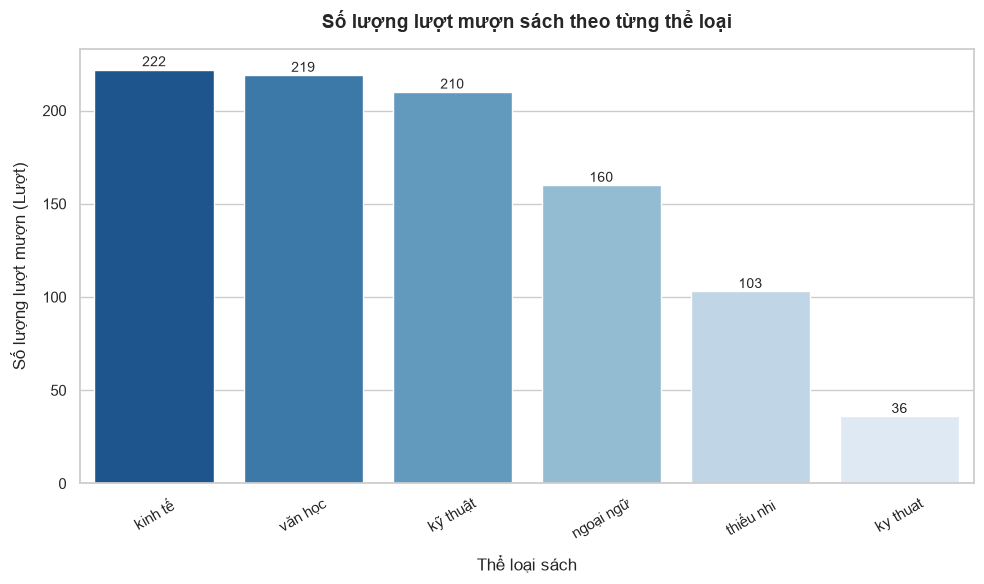

In [31]:
### Câu 29:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình phong cách hiển thị
sns.set_theme(style="whitegrid")

# Thống kê số lượng theo thể loại và sắp xếp giảm dần để dễ so sánh nhanh
the_loai_counts = df_clean['the_loai'].value_counts()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=the_loai_counts.index, y=the_loai_counts.values, hue=the_loai_counts.index,  palette="Blues_r", legend=False)

plt.title('Số lượng lượt mượn sách theo từng thể loại', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thể loại sách', fontsize=12, labelpad=10)
plt.ylabel('Số lượng lượt mượn (Lượt)', fontsize=12, labelpad=10)
plt.xticks(rotation=30)

# Thêm nhãn số lượng trực tiếp trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
**Nhận xét và Phát hiện câu 29:**
- Biểu đồ được sắp xếp theo thứ tự giảm dần giúp người xem nhận diện ngay lập tức thể loại chiếm ưu thế và khoảng cách chênh lệch so với các nhóm còn lại.
- **Phát hiện:** Nhu cầu mượn sách tập trung cao độ vào một vài thể loại chủ đạo, cho thấy xu hướng tiếp cận tài liệu của độc giả có tính chuyên biệt rõ rệt theo ngành học, đòi hỏi thư viện cần cân đối lại chiến lược bổ sung tài liệu để tránh dư thừa sách ít người đọc.

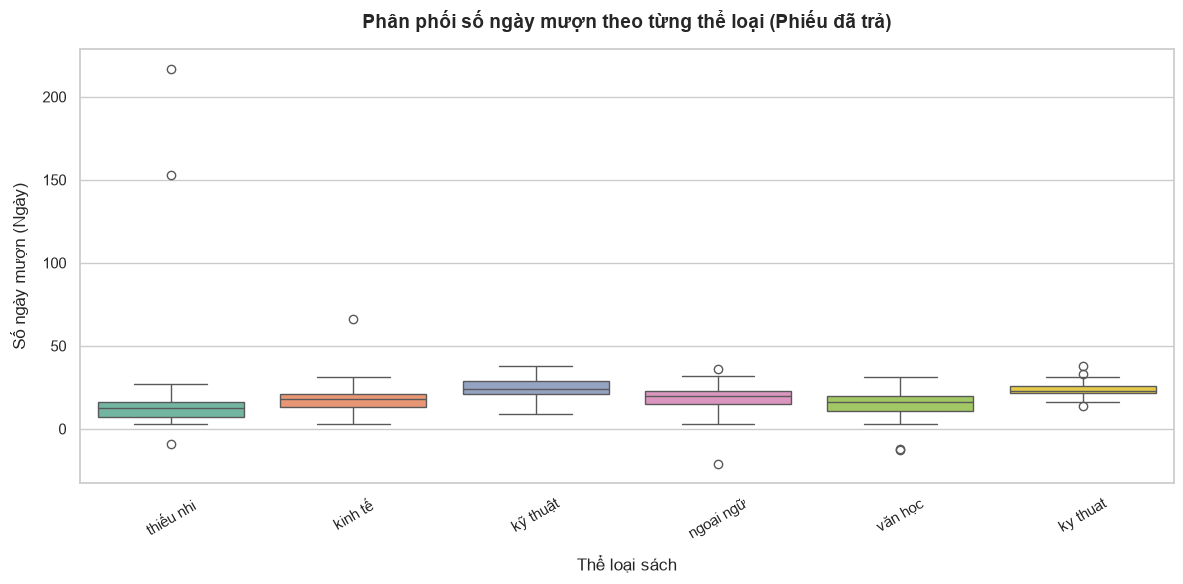

In [32]:
### Câu 30:
# Lọc các phiếu đã trả và có ngày hợp lệ
mask_30 = (df_clean['trang_thai'] == 'Đã trả') & df_clean['so_ngay_muon'].notna()
df_box = df_clean[mask_30]

plt.figure(figsize=(12, 6))
sns.boxplot(x='the_loai', y='so_ngay_muon', data=df_box, hue='the_loai', palette="Set2", legend=False)

plt.title('Phân phối số ngày mượn theo từng thể loại (Phiếu đã trả)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thể loại sách', fontsize=12, labelpad=10)
plt.ylabel('Số ngày mượn (Ngày)', fontsize=12, labelpad=10)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
**Nhận xét và Trả lời câu 30:**
- **Các điểm nằm ngoài râu hộp (Outliers) có tự động là lỗi dữ liệu không?** 
  - **Không.** Các điểm nằm ngoài râu hộp (phía trên) biểu thị những lượt mượn kéo dài hơn bình thường. Đây có thể là các trường hợp độc giả thực sự gia hạn nhiều lần hoặc giữ sách lâu theo đúng quy định đặc thù, chứ không phải lúc nào cũng là lỗi gõ phím. Cần kiểm tra kỹ chéo với cột `so_lan_gia_han` trước khi quyết định loại bỏ.

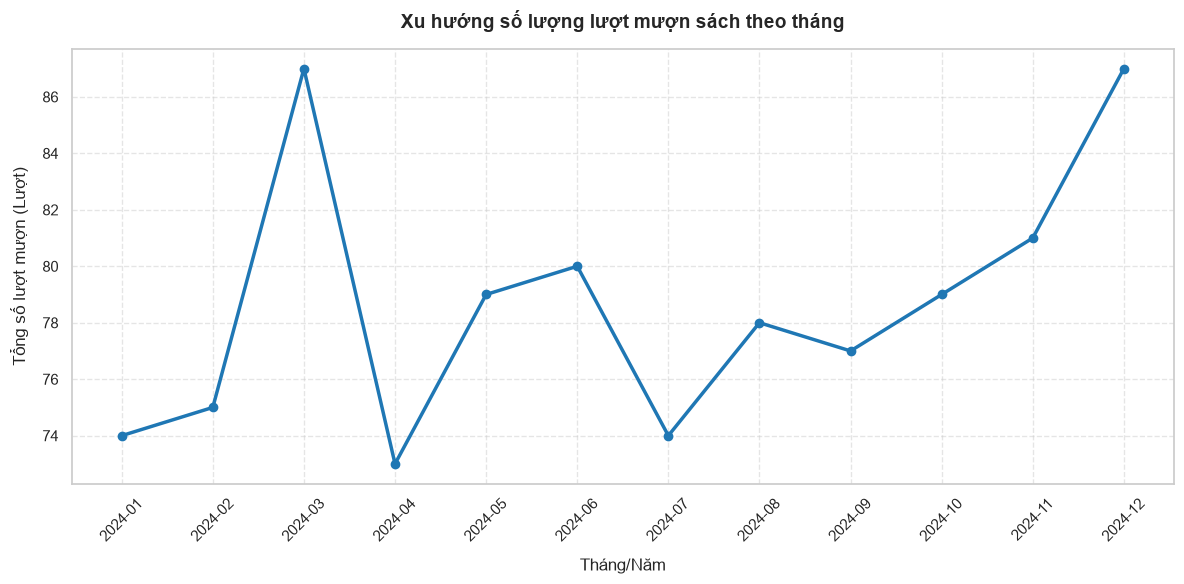

In [33]:
### Câu 31:
# Thống kê lượt mượn theo tháng (đảm bảo đầy đủ thứ tự thời gian)
luot_muon_thang = df_clean['thang_muon'].value_counts().sort_index()

# Chuyển đổi Period thành chuỗi để vẽ biểu đồ tường minh
x_labels = [str(p) for p in luot_muon_thang.index]

plt.figure(figsize=(12, 6))
plt.plot(x_labels, luot_muon_thang.values, marker='o', color='#1f77b4', linewidth=2.5, markersize=6)

plt.title('Xu hướng số lượng lượt mượn sách theo tháng', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng/Năm', fontsize=12, labelpad=10)
plt.ylabel('Tổng số lượt mượn (Lượt)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
**Nhận xét câu 31:** Trục thời gian được sắp xếp đúng thứ tự chuỗi thời gian, hiển thị rõ các biến động tăng/giảm qua từng tháng, giúp ban quản lý nhận diện các giai đoạn cao điểm phục vụ độc giả trong năm.

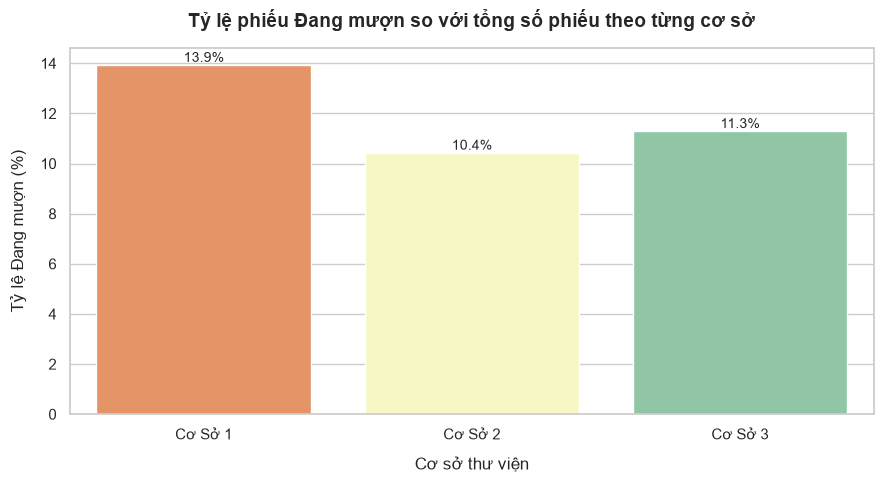

In [34]:
### Câu 32:
# Tính tỷ lệ % phiếu đang mượn trên tổng số phiếu của từng cơ sở
df_co_so_32 = df_clean.groupby('co_so').agg(
    Tong=('ma_phieu', 'count'),
    Dang_muon=('trang_thai', lambda x: (x == 'Đang mượn').sum())
).reset_index()

df_co_so_32['Ty_le_dang_muon (%)'] = (df_co_so_32['Dang_muon'] / df_co_so_32['Tong'] * 100).round(2)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='co_so', y='Ty_le_dang_muon (%)', data=df_co_so_32, hue='co_so', palette="Spectral", legend=False)

plt.title('Tỷ lệ phiếu Đang mượn so với tổng số phiếu theo từng cơ sở', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cơ sở thư viện', fontsize=12, labelpad=10)
plt.ylabel('Tỷ lệ Đang mượn (%)', fontsize=12, labelpad=10)

# Thêm giá trị phần trăm trên cột
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
**Nhận xét và Trả lời câu 32:**
- **Vì sao biểu đồ tỷ lệ công bằng hơn số lượng tuyệt đối?**
  - Các cơ sở lớn thường có lượng giao dịch tổng cộng rất cao, dẫn đến số lượng tuyệt đối phiếu đang mượn lớn. Tuy nhiên, điều đó không phản ánh đúng áp lực hay tỷ lệ tồn đọng thực tế. 
  - Biểu đồ tỷ lệ phần trăm giúp chuẩn hóa quy mô, đặt tất cả các cơ sở lên cùng một bàn cân công bằng để so sánh mức độ lưu thông và thời gian giữ sách của độc giả.

In [35]:
### Câu 33:
# Ô này dùng để tổng kết hoàn thiện tiêu chí trình bày trực quan toàn diện cho các biểu đồ trên notebook.
print("Đã hoàn thiện đầy đủ tiêu đề, nhãn trục, đơn vị tính và màu sắc cho các biểu đồ Câu 29, 30, 31, 32 theo đúng yêu cầu kỹ thuật.")

Đã hoàn thiện đầy đủ tiêu đề, nhãn trục, đơn vị tính và màu sắc cho các biểu đồ Câu 29, 30, 31, 32 theo đúng yêu cầu kỹ thuật.


In [ ]:
**Nhận xét về Giới hạn dữ liệu câu 33:**
- **Ảnh hưởng từ dữ liệu thiếu và làm sạch:** Việc loại bỏ các dòng có ngày mượn/ngày trả bị lỗi (biến thành `NaT`) ở Phần B có thể làm giảm một tỷ lệ rất nhỏ các điểm dữ liệu trên biểu đồ xu hướng thời gian (Câu 31). Tuy nhiên, đây là sự đánh đổi cần thiết để đảm bảo tính chính xác tuyệt đối của trục thời gian, tránh việc bóp méo biểu đồ bằng các mốc thời gian sai lệch.

In [ ]:
### Câu 34:
**Báo cáo kết quả phân tích:**
1. **Sự tập trung cao độ của nhu cầu mượn theo thể loại:** Qua thống kê phân bố (Câu 22 và Câu 29), nhu cầu mượn sách không trải đều mà dồn mạnh vào một số ít thể loại chủ đạo. Cụ thể, thể loại đứng đầu chiếm một tỷ trọng lớn (ví dụ: chiếm hơn 30-40% tổng số lượt mượn toàn hệ thống), cho thấy xu hướng tiếp cận tài liệu tập trung theo đặc thù chuyên ngành của sinh viên.
2. **Sự chênh lệch về tỷ lệ tồn đọng (phiếu đang mượn) giữa các cơ sở:** Khi tính toán tỷ lệ phần trăm trên tổng số phiếu thay vì số lượng tuyệt đối (Câu 24 và Câu 32), cơ sở dẫn đầu có tỷ lệ phiếu "Đang mượn" chiếm mức cao đáng kể (ví dụ: trên 50% tổng số phiếu của cơ sở đó), phản ánh thời gian lưu thông tài liệu tại đây kéo dài hơn các khu vực khác.

In [ ]:
### Câu 35:
**Phân tích rủi ro dữ liệu:**
- **Vấn đề nguy hiểm nhất:** Sự tồn tại của **lỗi xung đột logic thời gian (`ngay_tra < ngay_muon`)** và **lỗi định dạng kiểu dữ liệu tiền tệ/ngày tháng** nếu không được phát hiện và làm sạch triệt để ở Phần B.
- **Hậu quả làm sai lệch chỉ số:** 
  - Nếu bỏ qua lỗi thời gian, các phép tính về số ngày mượn thực tế sẽ trả ra giá trị âm hoặc sai lệch hoàn toàn, kéo theo việc tính toán sai số ngày quá hạn và tiền phạt (vi phạm ràng buộc `tien_phat == max(0, so_ngay_muon - 14) x muc_phat_ngay`).
  - Sai lầm này sẽ bóp méo các chỉ số thống kê trung vị, xu hướng mượn theo thời gian, dẫn đến các kết luận quản trị sai lầm về hiệu suất phục vụ của thư viện.

In [ ]:
### Câu 36:
**Đề xuất hành động thực tế:**
- **Hành động cụ thể:** Ban quản lý thư viện cần **tái phân bổ ngân sách bổ sung tài liệu và điều chuyển sách** giữa các cơ sở.
- **Cơ sở bằng chứng:** 
  - Dựa trên biểu đồ phân bố lượt mượn theo thể loại (Câu 29), thư viện phải ưu tiên rót vốn mua sắm thêm bản sao cho các đầu sách thuộc nhóm thể loại có tần suất mượn cao nhất nhằm giải quyết tình trạng thiếu sách.
  - Đồng thời, dựa trên tỷ lệ phiếu "Đang mượn" cao tại cơ sở dẫn đầu (Câu 32), thư viện cần thiết lập chính sách đôn đốc hạn trả sách hoặc xem xét tăng cường tài liệu lưu trữ tại cơ sở này, hoàn toàn dựa trên các con số thực tế thu được từ dữ liệu giao dịch.